# Does the pupil index the state of visual cortex? Decoding population state from pupillometry

NeuroDataReHack 2026 · Allen Visual Coding – Neuropixels (DANDI:000021)

**Question:** to what extent does the pupil index the population state of VISp during spontaneous activity, and with what temporal lag?

Single-session analysis, organised in five blocks:

- **Block 0 — Feasibility.** Is there enough spontaneous activity and enough clean VISp units?
- **Block 1 — Signal alignment and dimensionality reduction.** Pupil, running speed and VISp spikes on a common grid; neural state `Y` from PCA fitted on the training split only.
- **Block 2 — Cross-correlation with a circular null.** Are pupil and state coupled, at what lag, and does the coupling survive a null that preserves autocorrelation?
- **Block 3 — Decoding with a lag sweep.** Reconstruct the state from the pupil with a GLM and a GRU, sweeping the delay tau.
- **Block 4 — Contrast.** Intrinsic forecasting of the state, without the pupil.
- **Block 5 — Conclusions and limitations.**

**Why spontaneous activity.** Under visual stimulation VISp is dominated by evoked responses and arousal becomes confounded with stimulus response; changing luminance also breaks the assumption that pupil size tracks arousal. The constant grey screen of the spontaneous block is what makes the pupil interpretable here.

**Data access.** Session NWB files are several GB and are not downloaded: `remfile` streams them and only the requested chunks are read (metadata, and the `spike_times` of the selected units).

---
## Block 0 — Environment, imports and NWB access

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- NWB / DANDI streaming ---
import h5py
import remfile
import pynwb
from dandi.dandiapi import DandiAPIClient

# --- Time series alignment on a common grid ---
import pynapple as nap

# --- Scaling, PCA, Ridge regression, R2 ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# --- Rank correlation and gaussian smoothing ---
from scipy.stats import rankdata
from scipy.ndimage import gaussian_filter1d

# --- GRU decoder (Block 3) ---
import torch
import torch.nn as nn

print("Environment versions:")
for nombre, mod in [("numpy", np), ("pandas", pd), ("pynwb", pynwb),
                    ("pynapple", nap), ("torch", torch)]:
    print(f"  {nombre:10s} {mod.__version__}")

Environment versions:
  numpy      2.5.1
  pandas     3.0.3
  pynwb      4.0.0
  pynapple   0.11.4
  torch      2.14.0+cpu


### 0.1 Compute device

`torch.cuda.is_available()` selects the GPU when one is present; everything runs on CPU otherwise, just slower. The seed is fixed for reproducibility.

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    print(f"GPU detected: {torch.cuda.get_device_name(0)}  (CUDA {torch.version.cuda})")
else:
    print("No GPU available: running on CPU.")
print("Compute device:", DEVICE)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)   # used by the Block 2 null

No GPU available: running on CPU.
Compute device: cpu


### 0.2 Configuration

All tunable parameters are here: change a value and re-run from this cell. QC thresholds are the Allen Institute defaults; the 50 ms bin and 100 ms smoothing are standard for population analyses.

In [4]:
# --- Data ---
DANDISET_ID    = "000021"
DANDI_FILEPATH = "sub-738651046/sub-738651046_ses-760693773.nwb"
REGION         = "VISp"          # Allen CCF acronym

# --- Time grid ---
BIN          = 0.050             # bin size (s)
SMOOTH_SIGMA = 0.100             # gaussian smoothing sigma (s)

# --- Spike-sorting QC (Allen defaults) ---
QC_QUALITY        = "good"
QC_ISI_MAX        = 0.5
QC_AMP_CUTOFF_MAX = 0.1
QC_PRESENCE_MIN   = 0.9

# --- Neural state (PCA) ---
N_PCA      = 3                   # components of the neural state Y
FRAC_TRAIN = 0.70                # sequential temporal split, no shuffling

# --- Block 2: cross-correlation and null ---
LAG_MAX     = 3.0                # lag range of the cross-correlation: +/- LAG_MAX (s)
N_PERM      = 2000               # circular permutations for the null
CORR_METHOD = "spearman"         # "spearman" (non-gaussian data) or "pearson"
SENAL_NEURAL = "PC1"             # "PC1" or "mean_z" (population mean z-score)

# --- Block 3: decoding with a tau sweep ---
TAU_GRID = np.round(np.arange(-2.0, 2.0 + 1e-9, 0.25), 3)   # -2 to +2 s, step 0.25
DEC_SEQ  = 20                    # bins of recent pupil seen by the GRU (20 x 50 ms = 1 s)
RUN_GRU  = True                  # False = GLM only
DETREND_STATE = False            # True = remove the linear train-fit trend before decoding

# --- GRU ---
GRU_HIDDEN = 32
GRU_EPOCHS = 80
GRU_LR     = 5e-3
GRU_BATCH  = 256

# --- Block 4 (optional) ---
RUN_BLOQUE4  = True
AR_LAGS      = 10                # bins of state history used as predictors
AR_HORIZONTES = [1, 5, 10]       # forecasting horizons (bins): 50, 250, 500 ms

print("Configuration loaded.")
print(f"  Region: {REGION} | bin: {BIN*1000:.0f} ms | smoothing: {SMOOTH_SIGMA*1000:.0f} ms")
print(f"  LAG_MAX: +/-{LAG_MAX:.1f} s | N_PERM: {N_PERM} | TAU_GRID: {TAU_GRID[0]}..{TAU_GRID[-1]} s")

Configuration loaded.
  Region: VISp | bin: 50 ms | smoothing: 100 ms
  LAG_MAX: +/-3.0 s | N_PERM: 2000 | TAU_GRID: -2.0..2.0 s


### 0.3 Opening the NWB file by streaming

`DandiAPIClient` resolves the S3 URL, `remfile` exposes it as if it were local, `h5py` wraps it and `pynwb` interprets it. The first read takes a few seconds; heavy arrays are read lazily, only when requested.

In [5]:
with DandiAPIClient() as client:
    dandiset = client.get_dandiset(DANDISET_ID, "draft")                    # "draft" = the version selected
    asset    = dandiset.get_asset_by_path(DANDI_FILEPATH)
    s3_url   = asset.get_content_url(follow_redirects=1, strip_query=True)

rem_file = remfile.File(s3_url)
h5_file  = h5py.File(rem_file, "r")
io       = pynwb.NWBHDF5IO(file=h5_file, load_namespaces=True)
nwb      = io.read()

print("Session   :", nwb.session_id)
print("Subject   :", nwb.subject.subject_id, "|", nwb.subject.genotype)
print("Units     :", len(nwb.units.id[:]))
print("Intervals :", list(nwb.intervals.keys()))

Session   : 760693773
Subject   : 738651046 | Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
Units     : 2285
Intervals : ['drifting_gratings_presentations', 'flashes_presentations', 'gabors_presentations', 'natural_movie_one_presentations', 'natural_movie_three_presentations', 'natural_scenes_presentations', 'spontaneous_presentations', 'static_gratings_presentations']


### 0.4 Feasibility check

The analysis assumes two things that are worth confirming before going further: enough spontaneous activity, and enough clean VISp units. This cell reports the total duration of the spontaneous block (summing `stop_time - start_time` over `spontaneous_presentations`) and the number of VISp units passing QC, then applies the inclusion criterion: at least 4-5 min of spontaneous activity and at least 30 units. Otherwise the `natural_movie_*` blocks would have to be added to gain recording time, at the cost of introducing a visual component.

In [6]:
# --- (1) Duration of the spontaneous block ---
spont = nwb.intervals["spontaneous_presentations"].to_dataframe()
dur_spont_s   = float((spont["stop_time"] - spont["start_time"]).sum())
dur_spont_min = dur_spont_s / 60.0
print(f"Spontaneous block: {len(spont)} intervals | total duration = {dur_spont_min:.2f} min")

# --- (2) VISp units passing QC ---
colnames = list(nwb.units.colnames)
cols_meta = [c for c in ["peak_channel_id", "quality", "isi_violations",
                         "amplitude_cutoff", "presence_ratio", "firing_rate", "snr"]
             if c in colnames]
units_meta = pd.DataFrame({c: nwb.units[c].data[:] for c in cols_meta},
                          index=pd.Index(nwb.units.id[:], name="unit_id"))
electrodos = nwb.electrodes.to_dataframe()
units_meta["location"] = units_meta["peak_channel_id"].map(electrodos["location"])
if "quality" in units_meta.columns:
    units_meta["quality"] = units_meta["quality"].astype(str)

# QC mask; each filter is applied only if its column exists
mask = units_meta["location"] == REGION
if "quality"        in units_meta: mask &= units_meta["quality"] == QC_QUALITY
if "isi_violations" in units_meta: mask &= units_meta["isi_violations"] <= QC_ISI_MAX
if "amplitude_cutoff" in units_meta: mask &= units_meta["amplitude_cutoff"] <= QC_AMP_CUTOFF_MAX
if "presence_ratio" in units_meta: mask &= units_meta["presence_ratio"] >= QC_PRESENCE_MIN

n_visp_qc = int(mask.sum())
print(f"Units in {REGION} passing QC: {n_visp_qc}")

# --- Decision ---
ok_tiempo   = dur_spont_min >= 4.0
ok_neuronas = n_visp_qc     >= 30
print("\n" + "="*56)
if ok_tiempo and ok_neuronas:
    print("Decision: enough spontaneous activity and enough clean units.")
else:
    print("Decision: consider adding the natural_movie_* blocks.")
    print("  (they add a visual component, which weakens reading pupil size as arousal).")
print(f"  spontaneous >= 4-5 min: {ok_tiempo}  ({dur_spont_min:.2f} min)")
print(f"  VISp units >= ~30     : {ok_neuronas}  ({n_visp_qc} units)")
print("="*56)

Spontaneous block: 15 intervals | total duration = 20.62 min
Units in VISp passing QC: 92

Decision: enough spontaneous activity and enough clean units.
  spontaneous >= 4-5 min: True  (20.62 min)
  VISp units >= ~30     : True  (92 units)


---
## Block 1 — Aligning pupil, running speed and spikes

- **Common grid.** Pupil (~30 Hz) and spikes (point events) cannot be compared without a shared clock and resolution, so everything is binned at 50 ms.
- **Smoothing (~100 ms).** Removes the 0/1 noise of single-neuron bins and exposes state-level coupling.
- **PCA.** The pupil is one-dimensional, so correlating it against ~90 individual neurons is not informative. PC1 captures the global state modulation.
- **Running speed.** Arousal and locomotion are dissociable but covary, and locomotion dominates cortical activity, so it has to be recorded to tell "the pupil indexes cortex" from "both follow running".
- **Train-only fit.** Scaler and PCA are fitted on the first 70 % of bins, so the definition of the state does not use future information.

### 1.1 VISp unit selection and QC (without loading `spike_times` yet)

In [7]:
unidades_sel   = units_meta[mask]
posiciones_sel = np.where(mask.values)[0]   # row indices, used later to read spike_times
print(f"Selected units in {REGION}: {len(unidades_sel)}")
display(unidades_sel[[c for c in ['firing_rate','snr','isi_violations',
                                  'amplitude_cutoff','presence_ratio'] if c in unidades_sel]].head())

Selected units in VISp: 92


,firing_rate,snr,isi_violations,amplitude_cutoff,presence_ratio
unit_id,,,,,
951791719,0.104840,3.141620,0.000000,0.061289,0.94
951791461,0.907548,2.719859,0.375749,0.005772,0.99
951790421,1.583539,4.014420,0.046271,0.000017,0.99
951790273,0.373028,2.342606,0.000000,0.003293,0.98
951790678,0.539885,5.405894,0.000000,0.005381,0.99


### 1.2 `IntervalSet` covering the whole spontaneous block

The temporal domain is the complete spontaneous block: the `IntervalSet` holds all of its intervals, and `pynapple` bins within each one and concatenates them, so only spontaneous time enters the analysis.

In [8]:
ep = nap.IntervalSet(start=spont["start_time"].values, end=spont["stop_time"].values)
print(f"Spontaneous IntervalSet: {len(ep)} intervals | {ep.tot_length()/60:.2f} min in total")

Spontaneous IntervalSet: 15 intervals | 20.62 min in total


### 1.3 Loading spikes into a `TsGroup`

`spike_times` are read only for the selected units. Binning against `ep` restricts them to the spontaneous block.

In [9]:
spikes_dict = {}
for uid, pos in zip(unidades_sel.index, posiciones_sel):
    st = np.asarray(nwb.units["spike_times"][pos])          # every spike of this unit
    st = st[(st >= float(ep.start[0])) & (st <= float(ep.end[-1]))]   # coarse crop to the spontaneous window
    spikes_dict[int(uid)] = nap.Ts(t=st)
tsgroup = nap.TsGroup(spikes_dict)
print(f"TsGroup: {len(tsgroup)} units loaded.")

TsGroup: 92 units loaded.


### 1.4 Pupil signal and NaN interpolation

`filtered_gaze_mapping/pupil_area` contains NaN from blinks. They are filled by linear interpolation before binning, so the gaps do not propagate.

In [10]:
pupil_obj = nwb.processing["filtered_gaze_mapping"]["pupil_area"]
pup_val   = np.asarray(pupil_obj.data[:], dtype=float)
pup_time  = np.asarray(pupil_obj.timestamps[:], dtype=float)
nan_mask  = np.isnan(pup_val)
pup_val[nan_mask] = np.interp(pup_time[nan_mask], pup_time[~nan_mask], pup_val[~nan_mask])
pupila = nap.Tsd(t=pup_time, d=pup_val)
print(f"Pupil: {len(pup_val)} samples | NaN interpolated: {int(nan_mask.sum())} "
      f"({100*nan_mask.mean():.1f} %)")

Pupil: 289845 samples | NaN interpolated: 45469 (15.7 %)


### 1.5 Locating the running-speed signal

The running signal sits at different paths across dataset versions, so `nwb.processing` and `nwb.acquisition` are scanned for names containing `run`, `speed` or `velocity`; the candidates are printed and the first one is used. `RUN_KEY_MANUAL` overrides the automatic choice when needed, as `"container/signal"` or `"acquisition/signal"`.

In [11]:
RUN_KEY_MANUAL = None   # set manually if the automatic scan misses, e.g. "running/running_speed"

def escanear_carrera(nwb):
    cand = []
    for mod_name, mod in nwb.processing.items():          # processing modules
        for name in mod.data_interfaces.keys():
            if any(k in name.lower() for k in ("run", "speed", "velocity")):
                cand.append(("processing", f"{mod_name}/{name}"))
    for name in nwb.acquisition.keys():                   # acquisition
        if any(k in name.lower() for k in ("run", "speed", "velocity")):
            cand.append(("acquisition", name))
    return cand

candidatos = escanear_carrera(nwb)
print("Running-speed signal candidates:")
for origen, ruta in candidatos:
    print(f"  [{origen}] {ruta}")

def cargar_ts_generico(nwb, origen, ruta):
    if origen == "processing":
        mod, name = ruta.split("/", 1)
        obj = nwb.processing[mod][name]
    else:
        obj = nwb.acquisition[ruta]
    d = np.asarray(obj.data[:], dtype=float)
    if getattr(obj, "timestamps", None) is not None:
        t = np.asarray(obj.timestamps[:], dtype=float)
    else:                                                  # rebuild timestamps from the sampling rate
        t0 = float(getattr(obj, "starting_time", 0.0) or 0.0)
        rate = float(obj.rate)
        t = t0 + np.arange(len(d)) / rate
    return t, d

if RUN_KEY_MANUAL is not None:
    origen = "acquisition" if RUN_KEY_MANUAL in nwb.acquisition else "processing"
    run_t, run_d = cargar_ts_generico(nwb, origen, RUN_KEY_MANUAL)
    print(f"\nRunning speed (manual): {RUN_KEY_MANUAL}")
elif candidatos:
    origen, ruta = candidatos[0]
    run_t, run_d = cargar_ts_generico(nwb, origen, ruta)
    print(f"\nRunning speed (auto): [{origen}] {ruta}")
else:
    run_t = run_d = None
    print("\nWarning: no running-speed signal found; continuing without it.")

if run_d is not None:
    run_d = np.abs(run_d)                                  # magnitude, to drop the encoder sign
    if np.isnan(run_d).any():
        ok = ~np.isnan(run_d)
        run_d[~ok] = np.interp(run_t[~ok], run_t[ok], run_d[ok])
    carrera = nap.Tsd(t=run_t, d=run_d)
    print(f"Running speed: {len(run_d)} samples | range [{run_d.min():.2f}, {run_d.max():.2f}]")

Running-speed signal candidates:
  [processing] running/running_speed
  [processing] running/running_speed_end_times
  [processing] running/running_wheel_rotation
  [acquisition] raw_running_wheel_rotation
  [acquisition] running_wheel_signal_voltage
  [acquisition] running_wheel_supply_voltage

Running speed (auto): [processing] running/running_speed
Running speed: 363865 samples | range [0.00, 372.94]


### 1.6 Binning onto a common grid

Spikes become smoothed rates, pupil and running speed are averaged per bin, all over `ep`. The series are then trimmed to the shortest common length and an `assert` checks that the timestamps match.

In [12]:
# (1) Spikes -> smoothed rates
conteos = tsgroup.count(BIN, ep=ep)          # TsdFrame (bins x units)
tasas   = conteos / BIN                        # Hz
tasas_s = tasas.smooth(SMOOTH_SIGMA)           # gaussian smoothing (sigma in s)

# (2) Pupil and running speed -> per-bin average on the same grid
pupila_b = pupila.bin_average(BIN, ep=ep)
tiene_carrera = ("carrera" in dir())
if tiene_carrera:
    carrera_b = carrera.bin_average(BIN, ep=ep)

# (3) Trim to a common length and check the timestamps
t_rate = np.asarray(tasas_s.t); t_pup = np.asarray(pupila_b.t)
L = min(len(t_rate), len(t_pup))
if tiene_carrera:
    L = min(L, len(np.asarray(carrera_b.t)))
tiempos = t_rate[:L]
RATES   = np.asarray(tasas_s.values)[:L]                   # (n_bins, n_units)
PUPILA  = np.asarray(pupila_b.values)[:L].astype(float)    # (n_bins,)
CARRERA = np.asarray(carrera_b.values)[:L].astype(float) if tiene_carrera else None

# Interpolate empty bins over the bin index
def interp_nan(v):
    if v is None or not np.isnan(v).any():
        return v
    idx = np.arange(len(v)); ok = ~np.isnan(v)
    v[~ok] = np.interp(idx[~ok], idx[ok], v[ok]); return v
PUPILA = interp_nan(PUPILA); CARRERA = interp_nan(CARRERA)

assert np.max(np.abs(t_rate[:L] - t_pup[:L])) < BIN, "Timestamps are not aligned"
n_bins, n_neuronas = RATES.shape
print(f"RATES: {RATES.shape} (bins x units) | PUPILA: {PUPILA.shape} | "
      f"running: {'yes' if tiene_carrera else 'no'}")
print(f"Common time base verified: {n_bins} bins of {BIN*1000:.0f} ms "
      f"({n_bins*BIN/60:.2f} min)")

RATES: (24745, 92) (bins x units) | PUPILA: (24745,) | running: yes
Common time base verified: 24745 bins of 50 ms (20.62 min)


### 1.7 Neural state `Y`

Sequential temporal split, no shuffling: first 70 % train, last 30 % test. Rates are standardised and the PCA is fitted on train only, then applied to the whole series. `Y` has shape `(n_bins x N_PCA)`.

In [13]:
cut = int(FRAC_TRAIN * n_bins)
print(f"Train: bins [0, {cut})  |  Test: bins [{cut}, {n_bins})")

scaler_rates = StandardScaler().fit(RATES[:cut])
RATES_z = scaler_rates.transform(RATES)

pca = PCA(n_components=N_PCA).fit(RATES_z[:cut])
Y   = pca.transform(RATES_z)                                # neural state (n_bins, N_PCA)
evr = pca.explained_variance_ratio_
print(f"Neural state Y: {Y.shape}")
print(f"Explained variance PC1-{N_PCA}: {np.round(evr*100,1)} %  (cumulative {evr.sum()*100:.1f} %)")

Train: bins [0, 17321)  |  Test: bins [17321, 24745)
Neural state Y: (24745, 3)
Explained variance PC1-3: [7.8 4.8 4.1] %  (cumulative 16.6 %)


### 1.8 Alignment check

Spike raster on top, pupil below (with running speed when available), sharing the time axis.

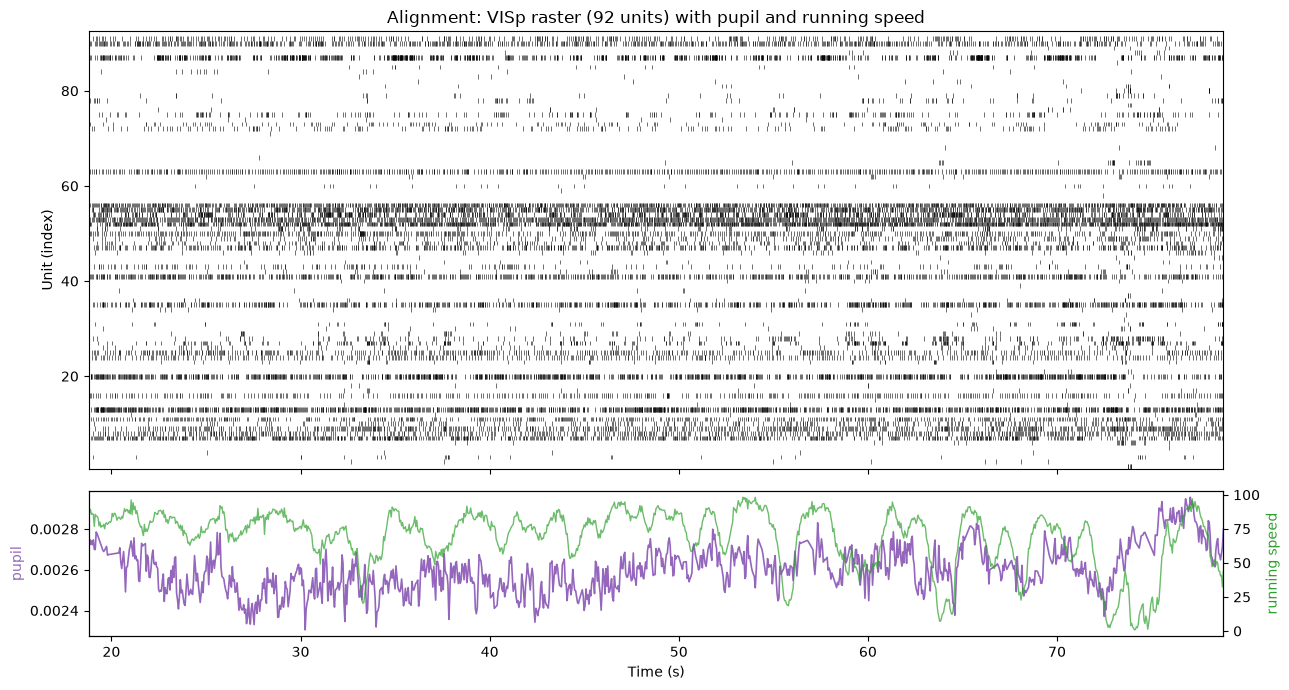

In [14]:
t0 = float(tiempos[0]); t1 = t0 + 60.0                     # first 60 s of the spontaneous block
fig, (axr, axp) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

# Raster restricted to the displayed window
for i, uid in enumerate(unidades_sel.index):
    st = np.asarray(tsgroup[int(uid)].t)
    st = st[(st >= t0) & (st <= t1)]
    axr.vlines(st, i + 0.5, i + 1.5, color="black", lw=0.4)
axr.set_ylabel("Unit (index)"); axr.set_ylim(0.5, len(unidades_sel) + 0.5)
axr.set_title(f"Alignment: VISp raster ({len(unidades_sel)} units) with pupil and running speed")

m = (tiempos >= t0) & (tiempos <= t1)
axp.plot(tiempos[m], PUPILA[m], color="tab:purple", lw=1.2, label="pupil (area)")
if CARRERA is not None:
    axc = axp.twinx()
    axc.plot(tiempos[m], CARRERA[m], color="tab:green", lw=1.0, alpha=0.7, label="running speed")
    axc.set_ylabel("running speed", color="tab:green")
axp.set_xlabel("Time (s)"); axp.set_ylabel("pupil", color="tab:purple")
axp.set_xlim(t0, t1)
plt.tight_layout(); plt.show()

---
## Block 2 — Cross-correlation with lag and circular null

**Cross-correlation rather than a single correlation.** The pupil is expected to lag neural activity, so a zero-lag analysis would miss or underestimate the relationship. The correlation between the 1D neural signal (PC1) and the pupil is computed for every delay within `±LAG_MAX` and the lag of the peak is reported. Since the sign of PC1 is arbitrary, the statistic is the maximum of |correlation|: what matters is the magnitude of the coupling, not its sign. Convention: positive lag means the pupil follows the state.

**Circular-shift null.** Both signals are slow and strongly autocorrelated, so a p-value that assumes independent samples would find spurious significance for any pair of slow signals. One signal is instead shifted cyclically by a random offset and the maximum correlation recomputed many times. The circular shift preserves each signal's autocorrelation and breaks only their temporal relationship.

In [15]:
# --- Signal preparation (Spearman = correlation of ranks) ---
def preparar(v):
    v = rankdata(v) if CORR_METHOD == "spearman" else np.asarray(v, float).copy()
    v = v - v.mean()
    return v / (np.linalg.norm(v) + 1e-12)          # unit norm, so the dot product is the correlation

# Lag range, shared across the block
Lb        = int(round(LAG_MAX / BIN))
lags_bins = np.arange(-Lb, Lb + 1)
lags_s    = lags_bins * BIN

def analizar_acople(neural, pupil1d, n_perm=N_PERM):
    # Circular cross-correlation (FFT) with a circular-shift null.
    # Statistic = max |correlation| over the lag window, since the sign of the PC is arbitrary.
    a = preparar(neural); b = preparar(pupil1d); N = len(a)
    # ifft(conj(A)*B)[m] = sum_t a[t]*b[t+m] -> positive lag m = pupil shifted forward = lagging.
    C = np.fft.irfft(np.conj(np.fft.rfft(a)) * np.fft.rfft(b), n=N)
    curva = C[(0 + lags_bins) % N]                  # observed correlation vs lag, signed
    i = int(np.argmax(np.abs(curva))); stat = float(abs(curva[i]))
    rloc = np.random.default_rng(SEED)              # fixed seed, reproducible null
    offs = rloc.integers(1, N, size=n_perm)
    null_lag = np.stack([C[(s + lags_bins) % N] for s in offs])   # (n_perm, n_lags), signed
    stat_null = np.abs(null_lag).max(axis=1)        # max |corr| per circular shift
    p = (1 + int(np.sum(stat_null >= stat))) / (n_perm + 1)
    return {"lag": float(lags_s[i]), "r": float(curva[i]), "absr": stat, "p": p,
            "curva": curva, "null_lag": null_lag}

print("Coupling functions ready. Lags:", lags_s[0], "..", lags_s[-1], "s")

Coupling functions ready. Lags: -3.0 .. 3.0 s


In [16]:
# --- 1D neural signal selected by SENAL_NEURAL ---
if SENAL_NEURAL == "PC1":
    neural = Y[:, 0].astype(float)
else:
    neural = RATES_z.mean(axis=1).astype(float)     # population mean z-score
pupil1d = PUPILA.astype(float)

ac = analizar_acople(neural, pupil1d)
xcorr_obs, null_lag = ac["curva"], ac["null_lag"]
lag_pico_s, r_pico, stat_obs, p_emp = ac["lag"], ac["r"], ac["absr"], ac["p"]
banda = np.percentile(np.abs(null_lag).max(axis=1), [2.5, 50, 97.5])

print(f"Correlation ({CORR_METHOD}) | signal = {SENAL_NEURAL}")
signo = "pupil lags" if lag_pico_s > 0 else "pupil leads" if lag_pico_s < 0 else "zero lag"
print(f"  Peak lag (max |r|)     : {lag_pico_s:+.3f} s  ({signo})")
print(f"  r at the peak          : {r_pico:+.3f}   (|r| = {stat_obs:.3f})")
print(f"  Null |r| P2.5/P50/P97.5: {banda[0]:.3f} / {banda[1]:.3f} / {banda[2]:.3f}")
print(f"  Empirical p-value      : {p_emp:.4f}  "
      f"({'SIGNIFICANT' if p_emp < 0.05 else 'not significant'} at 5%)")

Correlation (spearman) | signal = PC1
  Peak lag (max |r|)     : -0.100 s  (pupil leads)
  r at the peak          : -0.285   (|r| = 0.285)
  Null |r| P2.5/P50/P97.5: 0.030 / 0.176 / 0.342
  Empirical p-value      : 0.2069  (not significant at 5%)


### 2.1 Coupling as a function of lag

Absolute cross-correlation between pupil and state against delay. The shaded band is the null ceiling (97.5th percentile of |correlation| per lag) and the vertical line marks the peak. A curve clearly above the band means the pupil indexes the population state at that delay; a curve inside the band means the coupling is indistinguishable from what two slow signals produce by chance.

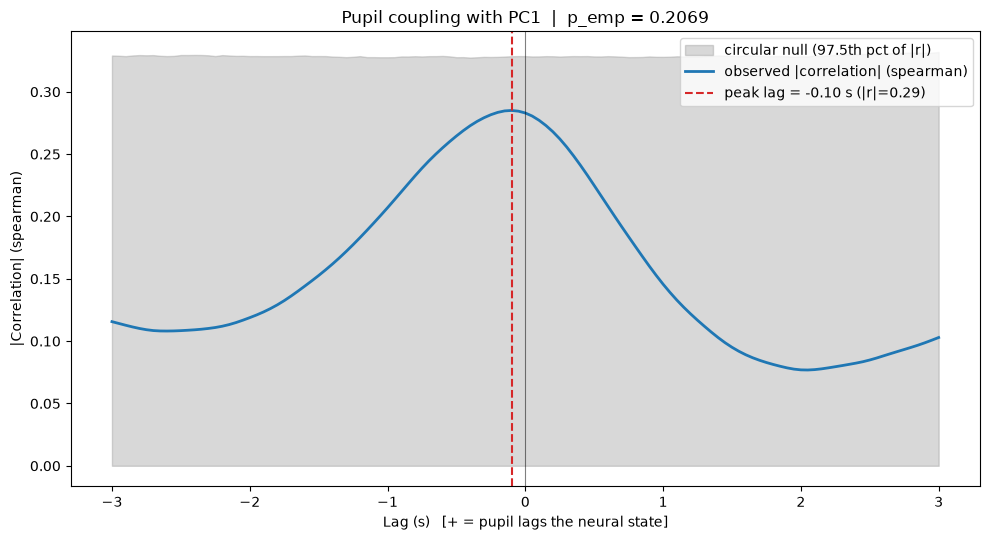

In [17]:
# |correlation|, since the sign of PC1 is arbitrary. Null band = 97.5th percentile of |null| per lag.
abs_obs = np.abs(xcorr_obs)
hi = np.percentile(np.abs(null_lag), 97.5, axis=0)         # null ceiling, lag by lag
lo = np.zeros_like(hi)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.fill_between(lags_s, lo, hi, color="gray", alpha=0.30, label="circular null (97.5th pct of |r|)")
ax.plot(lags_s, abs_obs, color="tab:blue", lw=2, label=f"observed |correlation| ({CORR_METHOD})")
ax.axvline(lag_pico_s, color="tab:red", ls="--",
           label=f"peak lag = {lag_pico_s:+.2f} s (|r|={stat_obs:.2f})")
ax.axvline(0, color="black", lw=0.8, alpha=0.5)
ax.set_xlabel("Lag (s)   [+ = pupil lags the neural state]")
ax.set_ylabel(f"|Correlation| ({CORR_METHOD})")
ax.set_title(f"Pupil coupling with {SENAL_NEURAL}  |  p_emp = {p_emp:.4f}")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()

### 2.2 Is PC1 the arousal axis?

PC1 explains only a small fraction of the variance during spontaneous activity, so the axis related to the pupil may not be PC1. PC1, PC2, PC3 and the population mean z-score (`mean_z`, a classical arousal proxy) are each tested against the pupil with its own circular null.

Sweeping several signals inflates the false-positive rate. The p-values below are per signal, without correction for multiple comparisons, and should be read as exploratory: to report one as a main result, fix it in `SENAL_NEURAL` and re-run the confirmatory analysis above.

In [18]:
candidatos_senal = {"PC1": Y[:, 0]}
if N_PCA > 1: candidatos_senal["PC2"] = Y[:, 1]
if N_PCA > 2: candidatos_senal["PC3"] = Y[:, 2]
candidatos_senal["mean_z (poblacion)"] = RATES_z.mean(axis=1)

filas = []
for nombre, sig in candidatos_senal.items():
    r = analizar_acople(np.asarray(sig, float), pupil1d)
    filas.append({"senal": nombre, "lag_pico_s": r["lag"], "r_signed": r["r"],
                  "abs_r": r["absr"], "p_emp": r["p"]})
diag = pd.DataFrame(filas).sort_values("abs_r", ascending=False).reset_index(drop=True)
print("Coupling with the pupil by choice of neural signal (sorted by |r|):")
display(diag.round(4))

mejor = diag.iloc[0]
print(f"\nBest signal: {mejor['senal']}  |r|={mejor['abs_r']:.3f} at lag {mejor['lag_pico_s']:+.2f} s  "
      f"p_emp={mejor['p_emp']:.4f}  ({'significant' if mejor['p_emp']<0.05 else 'not significant'})")
print("(per-signal p-values, exploratory, no correction for multiple comparisons).")

Coupling with the pupil by choice of neural signal (sorted by |r|):


,senal,lag_pico_s,r_signed,abs_r,p_emp
0,PC1,-0.10,-0.2850,0.2850,0.2069
1,PC2,0.35,0.2837,0.2837,0.3993
2,PC3,1.10,0.2202,0.2202,0.0865
3,mean_z (poblacion),-0.70,-0.0940,0.0940,0.6672



Best signal: PC1  |r|=0.285 at lag -0.10 s  p_emp=0.2069  (not significant)
(per-signal p-values, exploratory, no correction for multiple comparisons).


### 2.3 Controlling for locomotion

Pupil and running speed covary, and locomotion dominates cortical activity, so without this control "the pupil indexes cortex" cannot be separated from "both follow running". Contemporaneous running speed is regressed out of the neural signal and out of the pupil, and the cross-correlation is recomputed on the residuals (partial coupling) with its own circular null. The couplings of running speed to state and to pupil are reported alongside.

The control removes only the linear, contemporaneous component of running: delayed or non-linear effects of locomotion may remain. It is a reasonable control, not a test of causal mediation.

Couplings  (|r|, lag, p):
  pupil <-> PC1  (simple)          : |r|=0.285  lag=-0.10s  p=0.2069
  pupil <-> PC1  (partial | running): |r|=0.071  lag=-1.00s  p=0.7921
  running <-> PC1                    : |r|=0.758  lag=-0.15s  p=0.0050
  running <-> pupil                             : |r|=0.403  lag=-0.15s  p=0.0050


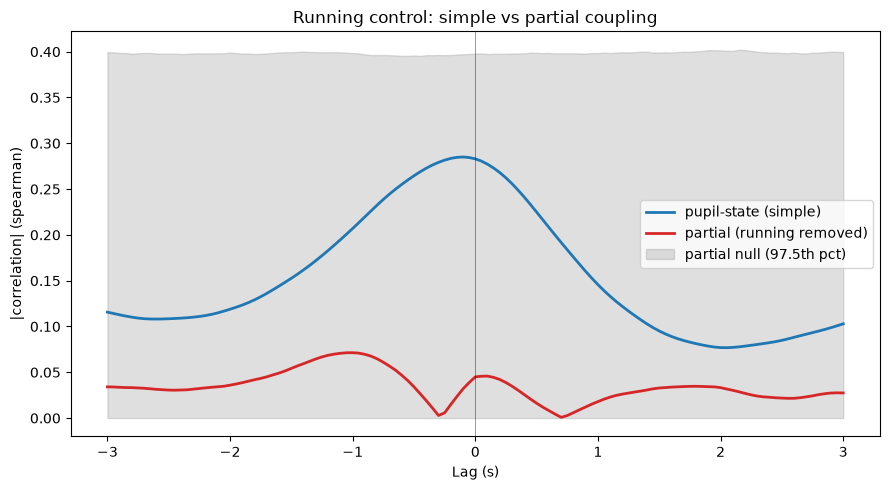

In [19]:
if CARRERA is not None:
    def quitar_carrera(sig, run):
        # Residual of 'sig' after regressing it on 'run' with an intercept: removes contemporaneous locomotion.
        A = np.column_stack([run, np.ones_like(run)])
        beta, *_ = np.linalg.lstsq(A, sig, rcond=None)
        return sig - A @ beta

    run_c      = CARRERA.astype(float)
    neural_res = quitar_carrera(neural, run_c)
    pupil_res  = quitar_carrera(pupil1d, run_c)

    ac_full = ac                                      # pupil <-> state, simple; already computed
    ac_part = analizar_acople(neural_res, pupil_res)  # pupil <-> state, partial (running removed)
    ac_nr   = analizar_acople(neural,  run_c)         # running <-> state
    ac_pr   = analizar_acople(pupil1d, run_c)         # running <-> pupil

    print("Couplings  (|r|, lag, p):")
    print(f"  pupil <-> {SENAL_NEURAL}  (simple)          : |r|={ac_full['absr']:.3f}  lag={ac_full['lag']:+.2f}s  p={ac_full['p']:.4f}")
    print(f"  pupil <-> {SENAL_NEURAL}  (partial | running): |r|={ac_part['absr']:.3f}  lag={ac_part['lag']:+.2f}s  p={ac_part['p']:.4f}")
    print(f"  running <-> {SENAL_NEURAL}                    : |r|={ac_nr['absr']:.3f}  lag={ac_nr['lag']:+.2f}s  p={ac_nr['p']:.4f}")
    print(f"  running <-> pupil                             : |r|={ac_pr['absr']:.3f}  lag={ac_pr['lag']:+.2f}s  p={ac_pr['p']:.4f}")

    fig, axx = plt.subplots(figsize=(9, 5))
    axx.plot(lags_s, np.abs(ac_full["curva"]), color="tab:blue", lw=2, label="pupil-state (simple)")
    axx.plot(lags_s, np.abs(ac_part["curva"]), color="tab:red",  lw=2, label="partial (running removed)")
    hi_p = np.percentile(np.abs(ac_part["null_lag"]), 97.5, axis=0)
    axx.fill_between(lags_s, 0, hi_p, color="gray", alpha=0.25, label="partial null (97.5th pct)")
    axx.axvline(0, color="black", lw=0.7, alpha=0.4)
    axx.set_xlabel("Lag (s)"); axx.set_ylabel(f"|correlation| ({CORR_METHOD})")
    axx.set_title("Running control: simple vs partial coupling")
    axx.legend(); plt.tight_layout(); plt.show()
else:
    print("No running-speed signal loaded; cannot control for locomotion.")

---
## Block 3 — Decoding with a lag sweep

A second, independent approach, which should point to the same delay. A decoder `pupil(t-tau ... t) -> state(t)` is fitted for each tau in `TAU_GRID`, comparing two models:

- **GLM (linear baseline).** With a continuous target, the Gaussian GLM is a regularised linear regression (`Ridge`, one per component).
- **GRU (non-linear).** Receives a window of recent pupil (`DEC_SEQ` bins), so its hidden state carries the recent past.

Pupil features are the smoothed signal and its derivative.

**Metric.** Over a 20-minute recording the neural state drifts, through electrode motion and slow changes in internal state. R² penalises any mismatch in mean between train and test, so a strongly negative R² can reflect drift rather than absence of signal. The correlation between prediction and target is therefore the primary metric, being invariant to a shift in mean, with R² as secondary. `DETREND_STATE` removes the linear trend, fitted on train, to check the effect without drift.

### 3.1 Pupil features and sample construction

In [20]:
# --- Pupil features: smoothed signal and derivative ---
pupil_sm  = gaussian_filter1d(PUPILA, sigma=SMOOTH_SIGMA / BIN)
pupil_dv  = np.gradient(pupil_sm) / BIN
Xfeat_raw = np.column_stack([pupil_sm, pupil_dv])           # (n_bins, 2)

def detrend_train(M, cut):
    # Remove from each column a line fitted on train only (indices 0..cut).
    x = np.arange(M.shape[0]); out = M.astype(float).copy()
    for j in range(M.shape[1]):
        p = np.polyfit(x[:cut], M[:cut, j], 1)
        out[:, j] = M[:, j] - np.polyval(p, x)
    return out

# Optional detrend of the state and the features
Y_dec = detrend_train(Y, cut) if DETREND_STATE else Y.astype(float)
Xf    = detrend_train(Xfeat_raw, cut) if DETREND_STATE else Xfeat_raw
print(f"DETREND_STATE = {DETREND_STATE}")

# Standardise on train only, so metrics are comparable across components
scaler_X = StandardScaler().fit(Xf[:cut]);    Xfeat = scaler_X.transform(Xf)
scaler_Y = StandardScaler().fit(Y_dec[:cut]); Yz    = scaler_Y.transform(Y_dec)

def r_pred(y_true, y_pred):
    # Mean per-component correlation between prediction and target. Invariant to a shift in mean, unlike R2.
    rs = []
    for j in range(y_true.shape[1]):
        if np.std(y_pred[:, j]) < 1e-9 or np.std(y_true[:, j]) < 1e-9:
            rs.append(0.0)
        else:
            rs.append(np.corrcoef(y_true[:, j], y_pred[:, j])[0, 1])
    return float(np.nanmean(rs))

def indices_tau(n, P, tau, cut):
    # Anchor i (target Y[i]); input = pupil window [i-tau-P+1 .. i-tau].
    # No leakage: train if the target is in train (i<cut); test if the whole input is in test (i-tau-P+1>=cut).
    tr, te = [], []
    for i in range(n):
        j0, j1 = i - tau - P + 1, i - tau
        if j0 < 0 or j1 < 0 or j1 >= n:
            continue
        if i < cut:          tr.append(i)
        elif j0 >= cut:      te.append(i)
    return np.array(tr, dtype=int), np.array(te, dtype=int)

def plano_tau(Xf, Yt, tau, P, cut):
    tr, te = indices_tau(len(Yt), P, tau, cut)
    feats = lambda idx: np.stack([Xf[i-tau-P+1:i-tau+1].reshape(-1) for i in idx])
    return feats(tr), Yt[tr], feats(te), Yt[te]

def seq_tau(Xf, Yt, tau, P, cut):
    tr, te = indices_tau(len(Yt), P, tau, cut)
    seqs = lambda idx: np.stack([Xf[i-tau-P+1:i-tau+1] for i in idx])
    return seqs(tr), Yt[tr], seqs(te), Yt[te]

def glm_multisalida(Xtr, Ytr, Xte):
    # Gaussian GLM = regularised linear regression; one Ridge per component.
    preds = [Ridge(alpha=1.0).fit(Xtr, Ytr[:, j]).predict(Xte) for j in range(Ytr.shape[1])]
    return np.stack(preds, axis=1)

class GRURegresor(nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super().__init__()
        self.gru = nn.GRU(n_in, n_hidden, batch_first=True)
        self.fc  = nn.Linear(n_hidden, n_out)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

def entrenar_gru(Xtr, Ytr, Xte, n_in, n_out):
    torch.manual_seed(SEED)
    model = GRURegresor(n_in, GRU_HIDDEN, n_out).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=GRU_LR)
    lossf = nn.MSELoss()
    Xt = torch.tensor(Xtr, dtype=torch.float32, device=DEVICE)
    Yt = torch.tensor(Ytr, dtype=torch.float32, device=DEVICE)
    n  = Xt.shape[0]
    model.train()
    for _ in range(GRU_EPOCHS):
        perm = torch.randperm(n, device=DEVICE)             # shuffles the order of the samples, not the time within each one
        for k in range(0, n, GRU_BATCH):
            idx = perm[k:k+GRU_BATCH]
            opt.zero_grad()
            loss = lossf(model(Xt[idx]), Yt[idx]); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(Xte, dtype=torch.float32, device=DEVICE)).cpu().numpy()

print("Decoding helpers ready. Pupil features:", Xfeat.shape)

DETREND_STATE = False
Decoding helpers ready. Pupil features: (24745, 2)


### 3.2 Sweeping tau

For each tau the samples are built, the models fitted and the metrics evaluated on the test split. The GLM always runs; the GRU only if `RUN_GRU = True`. Convention: positive tau means using past pupil to predict the present state.

In [21]:
res = []
for tau_s in TAU_GRID:
    tau = int(round(tau_s / BIN))
    # GLM: P=1 (pupil and its derivative at t-tau)
    Xtr, Ytr, Xte, Yte = plano_tau(Xfeat, Yz, tau, P=1, cut=cut)
    if len(Yte) > 5:
        pg = glm_multisalida(Xtr, Ytr, Xte)
        r2_glm, r_glm = r2_score(Yte, pg), r_pred(Yte, pg)
    else:
        r2_glm = r_glm = np.nan
    r2_gru = r_gru = np.nan
    if RUN_GRU:
        Xs, Ys, Xes, Yes = seq_tau(Xfeat, Yz, tau, P=DEC_SEQ, cut=cut)
        if len(Yes) > 5:
            pr = entrenar_gru(Xs, Ys, Xes, n_in=Xfeat.shape[1], n_out=N_PCA)
            r2_gru, r_gru = r2_score(Yes, pr), r_pred(Yes, pr)
    res.append({"tau_s": tau_s, "r_GLM": r_glm, "r_GRU": r_gru,
                "R2_GLM": r2_glm, "R2_GRU": r2_gru})
    print(f"  tau={tau_s:+.2f}s  r_GLM={r_glm:+.3f} R2_GLM={r2_glm:+.3f}"
          + (f" | r_GRU={r_gru:+.3f} R2_GRU={r2_gru:+.3f}" if RUN_GRU else ""))

df_tau = pd.DataFrame(res)
# optimal tau by correlation, the robust metric, not by R2
tau_opt_glm = df_tau.loc[df_tau["r_GLM"].idxmax(), "tau_s"]
print(f"\nOptimal tau (GLM, by r): {tau_opt_glm:+.2f} s  (Block 2 peak lag: {lag_pico_s:+.2f} s)")
if RUN_GRU and df_tau["r_GRU"].notna().any():
    print(f"Optimal tau (GRU, by r): {df_tau.loc[df_tau['r_GRU'].idxmax(), 'tau_s']:+.2f} s")
display(df_tau.round(3))

  tau=-2.00s  r_GLM=+0.078 R2_GLM=-0.862 | r_GRU=+0.104 R2_GRU=-0.765
  tau=-1.75s  r_GLM=+0.124 R2_GLM=-0.842 | r_GRU=+0.134 R2_GRU=-0.819
  tau=-1.50s  r_GLM=+0.183 R2_GLM=-0.816 | r_GRU=+0.186 R2_GRU=-0.750
  tau=-1.25s  r_GLM=+0.216 R2_GLM=-0.800 | r_GRU=+0.229 R2_GRU=-0.770
  tau=-1.00s  r_GLM=+0.244 R2_GLM=-0.780 | r_GRU=+0.245 R2_GRU=-0.728
  tau=-0.75s  r_GLM=+0.260 R2_GLM=-0.764 | r_GRU=+0.280 R2_GRU=-0.658
  tau=-0.50s  r_GLM=+0.288 R2_GLM=-0.754 | r_GRU=+0.297 R2_GRU=-0.637
  tau=-0.25s  r_GLM=+0.312 R2_GLM=-0.742 | r_GRU=+0.286 R2_GRU=-0.585
  tau=+0.00s  r_GLM=+0.307 R2_GLM=-0.766 | r_GRU=+0.253 R2_GRU=-0.760
  tau=+0.25s  r_GLM=+0.254 R2_GLM=-0.804 | r_GRU=+0.203 R2_GRU=-0.759
  tau=+0.50s  r_GLM=+0.202 R2_GLM=-0.842 | r_GRU=+0.178 R2_GRU=-0.740
  tau=+0.75s  r_GLM=+0.172 R2_GLM=-0.869 | r_GRU=+0.152 R2_GRU=-0.794
  tau=+1.00s  r_GLM=+0.130 R2_GLM=-0.900 | r_GRU=+0.113 R2_GRU=-0.899
  tau=+1.25s  r_GLM=+0.093 R2_GLM=-0.931 | r_GRU=+0.108 R2_GRU=-0.885
  tau=+1.50s  r_GLM=

,tau_s,r_GLM,r_GRU,R2_GLM,R2_GRU
0,-2.00,0.078,0.104,-0.862,-0.765
1,-1.75,0.124,0.134,-0.842,-0.819
2,-1.50,0.183,0.186,-0.816,-0.750
3,-1.25,0.216,0.229,-0.800,-0.770
4,-1.00,0.244,0.245,-0.780,-0.728
5,-0.75,0.260,0.280,-0.764,-0.658
6,-0.50,0.288,0.297,-0.754,-0.637
7,-0.25,0.312,0.286,-0.742,-0.585
8,0.00,0.307,0.253,-0.766,-0.760
9,0.25,0.254,0.203,-0.804,-0.759


### 3.3 Comparing the two methods

If the optimal tau of the decoder matches the peak lag of the cross-correlation, two independent methods agree on the same number. Both metrics are shown: prediction-target correlation (left, robust to drift, the reference here) and R² (right, sensitive to drift).

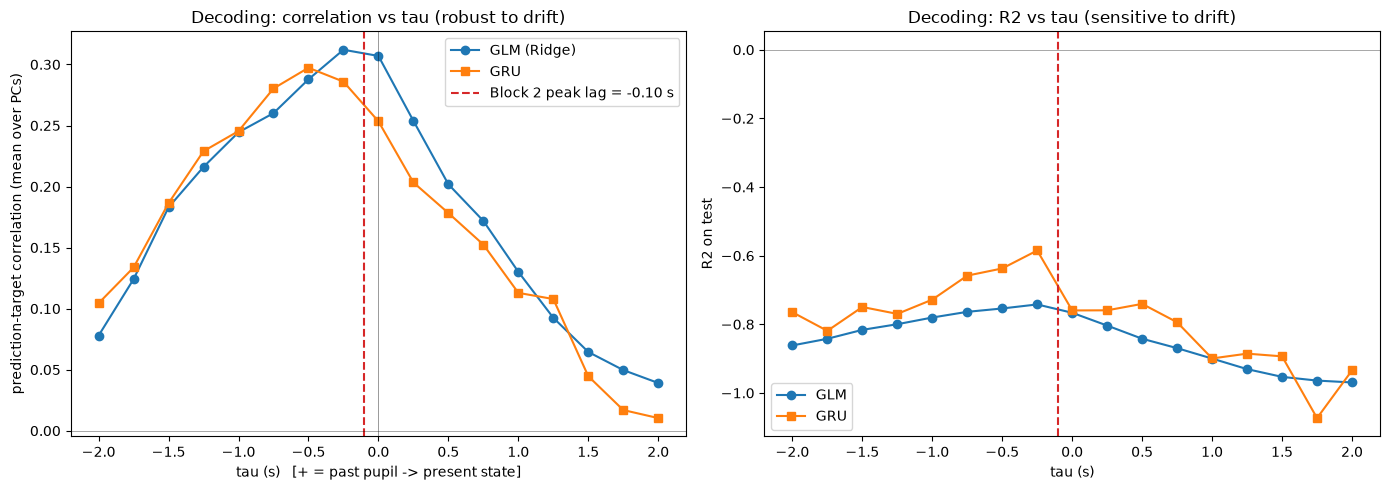

In [22]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))

# (left) primary metric: prediction-target correlation
a1.plot(df_tau["tau_s"], df_tau["r_GLM"], "o-", color="tab:blue", label="GLM (Ridge)")
if RUN_GRU and df_tau["r_GRU"].notna().any():
    a1.plot(df_tau["tau_s"], df_tau["r_GRU"], "s-", color="tab:orange", label="GRU")
a1.axvline(lag_pico_s, color="tab:red", ls="--", label=f"Block 2 peak lag = {lag_pico_s:+.2f} s")
a1.axvline(0, color="black", lw=0.7, alpha=0.4); a1.axhline(0, color="black", lw=0.6, alpha=0.4)
a1.set_xlabel("tau (s)   [+ = past pupil -> present state]")
a1.set_ylabel("prediction-target correlation (mean over PCs)")
a1.set_title("Decoding: correlation vs tau (robust to drift)"); a1.legend()

# (right) secondary metric: R2, sensitive to drift
a2.plot(df_tau["tau_s"], df_tau["R2_GLM"], "o-", color="tab:blue", label="GLM")
if RUN_GRU and df_tau["R2_GRU"].notna().any():
    a2.plot(df_tau["tau_s"], df_tau["R2_GRU"], "s-", color="tab:orange", label="GRU")
a2.axvline(lag_pico_s, color="tab:red", ls="--"); a2.axhline(0, color="black", lw=0.6, alpha=0.4)
a2.set_xlabel("tau (s)"); a2.set_ylabel("R2 on test")
a2.set_title("Decoding: R2 vs tau (sensitive to drift)"); a2.legend()
plt.tight_layout(); plt.show()

### 3.4 Significance of the decoding peak

The decoder peaks at r = 0.31, close to the non-significant |r| of Block 2, so it needs a p-value of its own. The pupil features are shifted cyclically, breaking their temporal relationship with the state while preserving their autocorrelation, the GLM is refitted across the tau sweep and the maximum r retained. The observed statistic is the real maximum r; the p-value is the fraction of the null that reaches or exceeds it. The null is computed for the GLM only, the GRU being too expensive to permute 500 times.

In [23]:
def r_glm_maxtau(Xf, Yt, cut):
    # Maximum prediction-target r of the GLM across the whole tau sweep.
    best = -np.inf
    for tau_s in TAU_GRID:
        tau = int(round(tau_s / BIN))
        Xtr, Ytr, Xte, Yte = plano_tau(Xf, Yt, tau, P=1, cut=cut)
        if len(Yte) > 5:
            best = max(best, r_pred(Yte, glm_multisalida(Xtr, Ytr, Xte)))
    return best

N_PERM_DEC = 500
obs_r = float(df_tau["r_GLM"].max())
rloc  = np.random.default_rng(SEED)
null_r = np.empty(N_PERM_DEC)
for k in range(N_PERM_DEC):
    off = int(rloc.integers(1, len(Yz)))
    null_r[k] = r_glm_maxtau(np.roll(Xfeat, off, axis=0), Yz, cut)   # pupil shifted cyclically
p_dec = (1 + int(np.sum(null_r >= obs_r))) / (N_PERM_DEC + 1)

print(f"Decoding GLM: observed r_max = {obs_r:.3f}")
print(f"Circular null ({N_PERM_DEC} perm): P50={np.percentile(null_r,50):.3f}  "
      f"P95={np.percentile(null_r,95):.3f}  P97.5={np.percentile(null_r,97.5):.3f}")
print(f"Empirical p-value = {p_dec:.4f}  "
      f"({'SIGNIFICANT' if p_dec < 0.05 else 'not significant'} at 5%)")

Decoding GLM: observed r_max = 0.312
Circular null (500 perm): P50=0.018  P95=0.050  P97.5=0.053
Empirical p-value = 0.0040  (SIGNIFICANT at 5%)


### 3.5 Drift check

Testing whether the negative R² reflects non-stationarity rather than absence of signal: the GLM is evaluated at the optimal tau with and without removing the linear trend fitted on train. If R² moves towards zero while the correlation holds, the negative R² was drift.

In [24]:
Xf_base = np.column_stack([pupil_sm, pupil_dv])
tau     = int(round(tau_opt_glm / BIN))
comp = []
for det in [False, True]:
    Ydec = detrend_train(Y, cut)        if det else Y.astype(float)
    Xf_r = detrend_train(Xf_base, cut)  if det else Xf_base
    Xf_z = StandardScaler().fit(Xf_r[:cut]).transform(Xf_r)
    Yz_d = StandardScaler().fit(Ydec[:cut]).transform(Ydec)
    Xtr, Ytr, Xte, Yte = plano_tau(Xf_z, Yz_d, tau, P=1, cut=cut)
    pg = glm_multisalida(Xtr, Ytr, Xte)
    comp.append({"DETREND": det, "R2": r2_score(Yte, pg), "r": r_pred(Yte, pg)})
display(pd.DataFrame(comp).round(3))
print(f"(GLM at the optimal tau = {tau_opt_glm:+.2f} s)")
print("If R2 moves towards 0 with detrend while r holds, the negative R2 was drift, not absence of signal.")

,DETREND,R2,r
0,False,-0.742,0.312
1,True,-0.146,0.410


(GLM at the optimal tau = -0.25 s)
If R2 moves towards 0 with detrend while r holds, the negative R2 was drift, not absence of signal.


---
## Block 4 — Contrast: intrinsic forecasting of the state

Pure autoregressive forecasting `state(t-P ... t) -> state(t+h)` at several horizons `h`, without the pupil. It does not address the main question and can be skipped with `RUN_BLOQUE4 = False`, but it provides a reference point: the complete state predicts its own future considerably better than the pupil reconstructs the present state. That gap makes explicit that population activity is multidimensional, while the pupil only sees its slow arousal axis.

In [25]:
if RUN_BLOQUE4:
    def indices_ar(n, P, h, cut):
        tr, te = [], []
        for i in range(P - 1, n - h):
            if   i + h < cut:      tr.append(i)
            elif i - P + 1 >= cut: te.append(i)
        return np.array(tr, dtype=int), np.array(te, dtype=int)

    r2_ar = []
    for h in AR_HORIZONTES:
        tr, te = indices_ar(n_bins, AR_LAGS, h, cut)
        feats = lambda idx: np.stack([Yz[i-AR_LAGS+1:i+1].reshape(-1) for i in idx])
        Xtr, Xte = feats(tr), feats(te)
        Ytr, Yte = Yz[tr + h], Yz[te + h]
        pred = glm_multisalida(Xtr, Ytr, Xte)
        r2_ar.append(r2_score(Yte, pred))
        print(f"  horizon h={h} bins ({h*BIN*1000:.0f} ms):  R2 = {r2_ar[-1]:.3f}")
    df_ar = pd.DataFrame({"h_bins": AR_HORIZONTES,
                          "h_ms": [h*BIN*1000 for h in AR_HORIZONTES], "R2_AR": r2_ar})
    display(df_ar.round(3))
else:
    df_ar = None
    print("Block 4 disabled (RUN_BLOQUE4=False).")

  horizon h=1 bins (50 ms):  R2 = 0.996
  horizon h=5 bins (250 ms):  R2 = 0.664
  horizon h=10 bins (500 ms):  R2 = 0.282


,h_bins,h_ms,R2_AR
0,1,50.0,0.996
1,5,250.0,0.664
2,10,500.0,0.282


---
## Block 5 — Summary figure and conclusions

The three panels in narrative order: coupling between pupil and state against lag with its null band, reconstruction of the state from the pupil across tau, and intrinsic forecasting of the state as a reference.

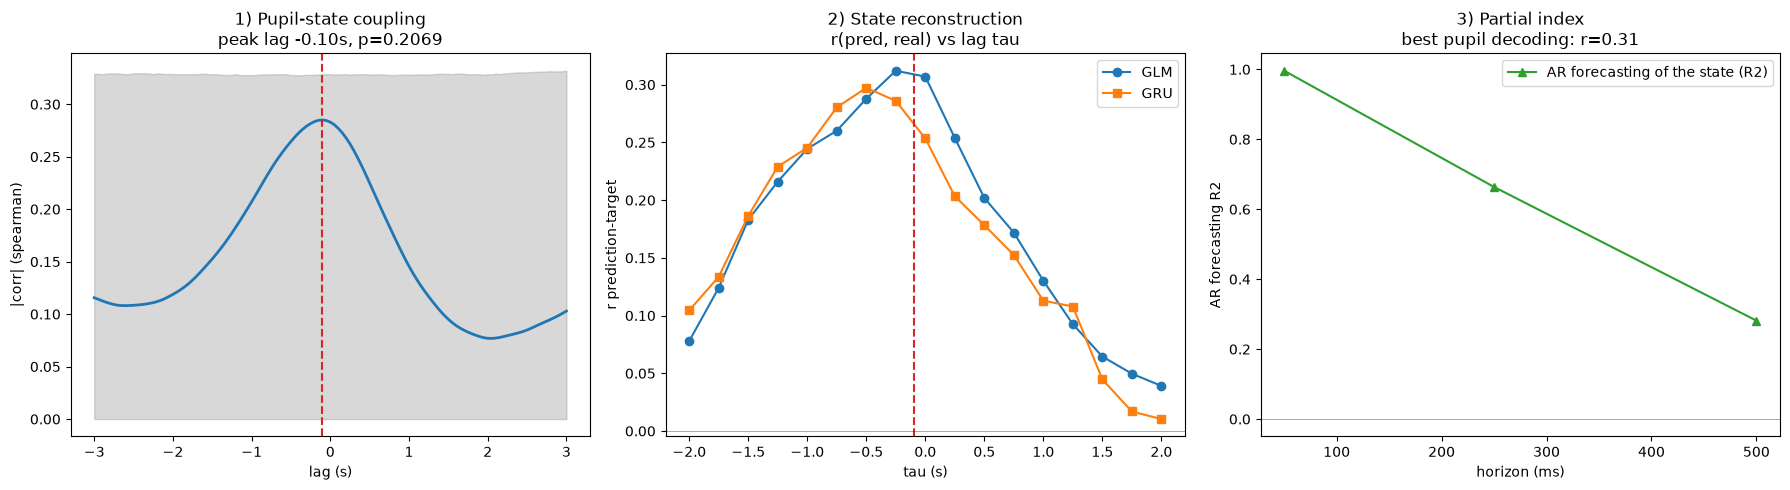

In [26]:
n_paneles = 3 if (RUN_BLOQUE4 and df_ar is not None) else 2
fig, axes = plt.subplots(1, n_paneles, figsize=(6*n_paneles, 5))

# (1) |Cross-correlation| and null
ax = axes[0]
ax.fill_between(lags_s, lo, hi, color="gray", alpha=0.30)
ax.plot(lags_s, abs_obs, color="tab:blue", lw=2)
ax.axvline(lag_pico_s, color="tab:red", ls="--")
ax.set_title(f"1) Pupil-state coupling\npeak lag {lag_pico_s:+.2f}s, p={p_emp:.4f}")
ax.set_xlabel("lag (s)"); ax.set_ylabel(f"|corr| ({CORR_METHOD})")

# (2) prediction-target correlation vs tau
ax = axes[1]
ax.plot(df_tau["tau_s"], df_tau["r_GLM"], "o-", color="tab:blue", label="GLM")
if RUN_GRU and df_tau["r_GRU"].notna().any():
    ax.plot(df_tau["tau_s"], df_tau["r_GRU"], "s-", color="tab:orange", label="GRU")
ax.axvline(lag_pico_s, color="tab:red", ls="--"); ax.axhline(0, color="black", lw=0.6, alpha=0.4)
ax.set_title("2) State reconstruction\nr(pred, real) vs lag tau"); ax.set_xlabel("tau (s)")
ax.set_ylabel("r prediction-target"); ax.legend()

# (3) Intrinsic forecasting (R2) vs best pupil decoding (r)
if n_paneles == 3:
    ax = axes[2]
    ax.plot(df_ar["h_ms"], df_ar["R2_AR"], "^-", color="tab:green", label="AR forecasting of the state (R2)")
    ax.axhline(0, color="black", lw=0.6, alpha=0.4)
    best_r = np.nanmax([df_tau["r_GLM"].max(),
                        df_tau["r_GRU"].max() if RUN_GRU else np.nan])
    ax.set_title(f"3) Partial index\nbest pupil decoding: r={best_r:.2f}")
    ax.set_xlabel("horizon (ms)"); ax.set_ylabel("AR forecasting R2"); ax.legend()

plt.tight_layout(); plt.show()

### 5.1 Conclusions and limitations

**No temporally specific coupling.** The best coupling between pupil and state (PC1, |r| = 0.285 at -0.10 s) does not exceed the circular null (p = 0.21): for two signals this slow, that level of correlation is what chance produces. No alternative definition of the neural signal survives the null either, and `mean_z` couples considerably less (|r| = 0.094). There is therefore no evidence of a privileged lag, and no clear arousal latency.

**Locomotion accounts for most of the apparent link.** Running speed dominates the cortical state (|r| = 0.758, p = 0.005) and drags the pupil with it (|r| = 0.403, p = 0.005). Once running is regressed out, the pupil-state coupling falls from 0.285 to 0.071 (p = 0.79). This is the confound the design was built to test, and here it is the answer.

**Decoding is real but not independent of running.** The decoder does reconstruct the state from the pupil above its own null (r = 0.312 at tau = -0.25 s, p = 0.004), with the optimum near zero lag, consistent with the cross-correlation peak. This does not contradict Block 2: the two tests ask different questions. The circular null asks whether the true pairing is more correlated than any random circular shift, a conservative test of temporal specificity for slow signals; the decoder asks whether the pupil predicts the state out of sample, which it does, but without controlling for running. Read together with the partial correlation, that predictive power is carried by locomotion.

**Drift, not absence of signal.** R² is negative across the whole tau range while the correlation peaks at 0.31. Removing the linear trend raises R² from -0.742 to -0.146 and the correlation to 0.410, confirming non-stationarity as the cause.

**Reference point.** The state predicts its own future with R² = 0.996 at 50 ms, 0.664 at 250 ms and 0.282 at 500 ms, far better than the pupil reconstructs the present. Population activity is multidimensional; the pupil at best sees its slow arousal axis.

**Limitations.**

- A single session and a single animal: the result is descriptive and does not generalise to a population.
- Reading pupil size as arousal is valid here because the spontaneous block holds luminance constant.
- The running control is linear and contemporaneous only; delayed or non-linear effects of locomotion may remain.
- PC1 explains 7.8 % of the variance, so it is a partial summary of the state.
- The running signal contains artefactual peaks. Spearman correlation limits their influence, but the decoder sees the raw values.

In [27]:
# Close the streaming connection and release resources.
io.close(); h5_file.close(); rem_file.close()
print("NWB file closed.")

NWB file closed.
